In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import f1_score
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.svm import SVC
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam
import joblib
import pickle
import warnings
warnings.filterwarnings("ignore")

In [4]:
start_program = time.time()
photos_csv = r"D:\Dataset\photos_data.csv"
photos_folder = r"D:\Dataset\photos"
# Load dataset
df = pd.read_csv(photos_csv)

In [20]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


In [22]:
df=df[['photo_id','label']]

In [24]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


DATA PREPROCESSING

In [28]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


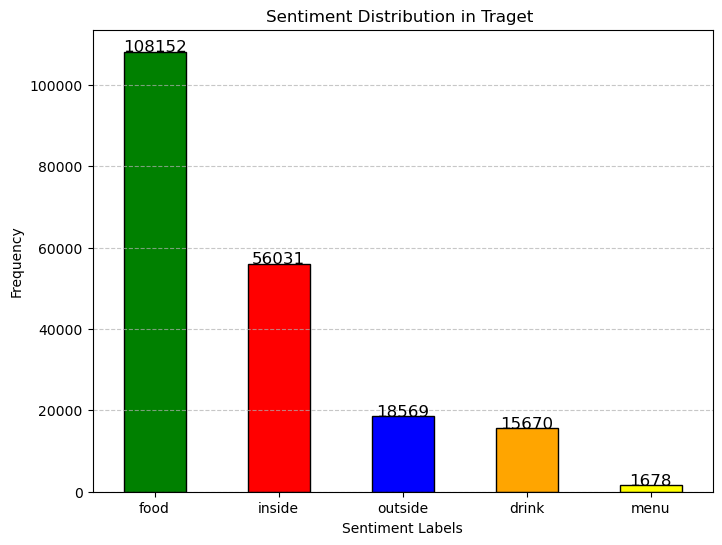

In [30]:
bar_plot(df['label'])

BALANCING THE DATASET

In [34]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
df_balanced

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
...,...,...
1495,b2Z_mH6elUbFfZ__rFmxWg,drink
1496,Hja-ujyebg1J0xyOzeaY_w,menu
1497,JLe7-8DzxieeiOHn-m1r5Q,outside
1498,FIw7ce992NJheBr9qEFHCA,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


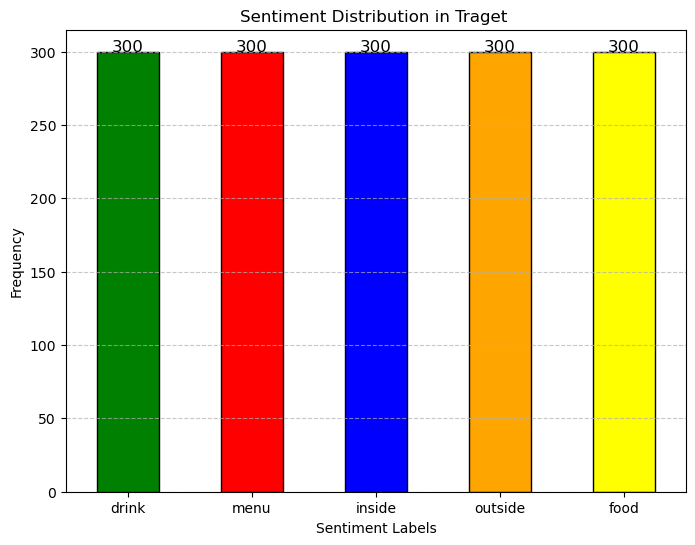

In [38]:
bar_plot(df_balanced['label'])

In [40]:
df = df_balanced

CONFIRMING THE COLUMN NAME

In [43]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [44]:
df.head(10)

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
5,4v5ns1DEc7DAz0r3xyrRqw,outside
6,bdtmWbdi6PRn_M1-aHYjcw,drink
7,t61K63S-DfSbufXgZpA_Ng,outside
8,pn4AVzlHlu4PhBpyDpb2wQ,menu
9,l_rMdwgrvjm2PyHyXBcBTw,food


In [47]:
# Get the first 10 records from the dictionary
first_10_records = dict(list(photo_id_to_path.items())[:10])

# Print them
print("First 10 records:", first_10_records)

First 10 records: {'--puCF1Lauwb3k6vrVVvfQ': 'D:\\Dataset\\photos\\--puCF1Lauwb3k6vrVVvfQ.jpg', '-10Ge63S6TdapDZV5ZGJLw': 'D:\\Dataset\\photos\\-10Ge63S6TdapDZV5ZGJLw.jpg', '-15xxjJWleNHNoApS8nXZA': 'D:\\Dataset\\photos\\-15xxjJWleNHNoApS8nXZA.jpg', '-3qJQmfAxo33Dp07QzkWtA': 'D:\\Dataset\\photos\\-3qJQmfAxo33Dp07QzkWtA.jpg', '-3yDzSGRk9m7z-N6bOH0Ag': 'D:\\Dataset\\photos\\-3yDzSGRk9m7z-N6bOH0Ag.jpg', '-5bUepz7K1gaHBD3LzApbQ': 'D:\\Dataset\\photos\\-5bUepz7K1gaHBD3LzApbQ.jpg', '-6buz7yJj7J-fAEBpzfPhw': 'D:\\Dataset\\photos\\-6buz7yJj7J-fAEBpzfPhw.jpg', '-BQqi2wtRzy3TjZj3ugjuw': 'D:\\Dataset\\photos\\-BQqi2wtRzy3TjZj3ugjuw.jpg', '-BW8LZAgLYSbC9Hka7v5yA': 'D:\\Dataset\\photos\\-BW8LZAgLYSbC9Hka7v5yA.jpg', '-BzkuAu2ShaH4qd1vp6xMg': 'D:\\Dataset\\photos\\-BzkuAu2ShaH4qd1vp6xMg.jpg'}


RESIZING THE IMAGE

In [50]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

Error occurred: cannot identify image file <_io.BytesIO object at 0x000002821005BB50>
Image path: D:\Dataset\photos\l_rMdwgrvjm2PyHyXBcBTw.jpg
1393
[[[[0.9529412  0.9529412  0.9607843 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.69411767 0.8117647  0.9137255 ]
   [0.7607843  0.8627451  0.9529412 ]
   [0.78431374 0.88235295 0.96862745]]

  [[0.95686275 0.95686275 0.9647059 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.8509804  0.9372549  1.        ]
   [0.8745098  0.95686275 1.        ]
   [0.8862745  0.9607843  1.        ]]

  [[0.9607843  0.9607843  0.96862745]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.89411765 0.95686275 1.        ]
   [0.8980392  0.9529412  0.99607843]
   [0.89411765 0.9411765  0.9882353 ]]

  ...

  [[0.5137255  0.41960785 0.37254903]
   [0.49803922 0.39607844 0.3372549 ]
   [0.40784314 0.30980393 0.22352941]
   ...
   [0.4274509

MAPPING THE LABELS

In [52]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [54]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

Shape of the image array:  (1393, 150528)
Shape of the target array:  (1393,)


Making functions for evaluations

In [56]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Step 2: Convert the confusion matrix to a DataFrame for better visualization
    cm_df = pd.DataFrame(cm, index=[reverse_label_mapping[i] for i in range(len(cm))], 
                         columns=[reverse_label_mapping[i] for i in range(len(cm))])
    
    print(cm_df)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", xticklabels=cm_df.columns, yticklabels=cm_df.columns)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [58]:
def plot_roc_curve(y_true, y_pred_bin):
     # Initialize LabelBinarizer
    lb = LabelBinarizer()

    # Binarize the true labels (one-hot encoding)
    y_true_bin = lb.fit_transform(y_true)   
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_true_bin.shape[1]):  # Iterate through all classes
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves in one plot
    plt.figure(figsize=(10, 8))
    
    # Plot ROC for each class
    for i in range(y_true_bin.shape[1]):
        label = lb.classes_[i]
        plt.plot(fpr[i], tpr[i], label=f'{reverse_label_mapping[label]} (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Labeling and Title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

    # Print AUC values for each class
    for i in range(y_true_bin.shape[1]):
        print(f'AUC for class {lb.classes_[i]}: {roc_auc[i]:.2f}')


SPLLITING THE DATA

In [61]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)

print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1114, 150528)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 150528)
Shape of y_test:  (279,)


class_count :  1    228
4    228
0    221
3    220
2    217
Name: count, dtype: int64


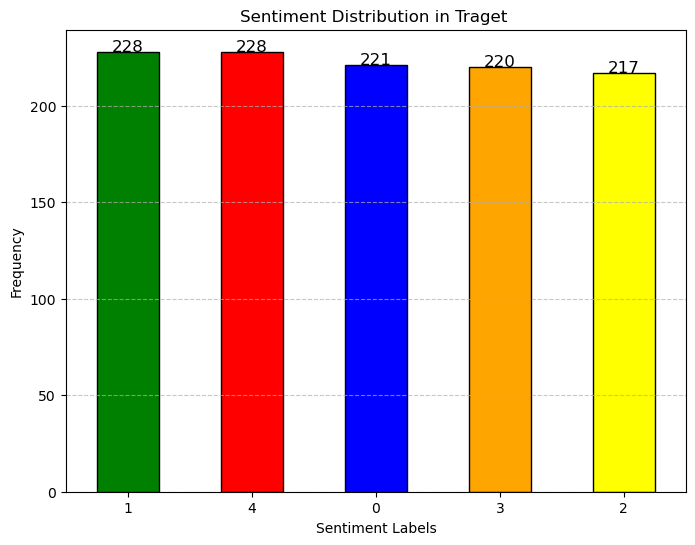

In [63]:
bar_plot(y_train)

In [75]:
# save trained models
def save_model(model, file_path, file_name):
    joblib.dump(model, file_path + file_name + ".joblib")
    with open(file_path + file_name + ".pkl", "wb") as file:
        pickle.dump(model, file)

BUILDING CNN MODEL

In [127]:
# Split data
y_one_hot = to_categorical(y, num_classes=5)
X_train, X_val, Y_train, Y_val = train_test_split(x_images, y_one_hot, test_size=0.2, random_state=42)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 337ms/step - accuracy: 0.2557 - loss: 3.1686 - val_accuracy: 0.4086 - val_loss: 1.4523
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.4309 - loss: 1.3383 - val_accuracy: 0.5054 - val_loss: 1.2943
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 324ms/step - accuracy: 0.5473 - loss: 1.1347 - val_accuracy: 0.5627 - val_loss: 1.1307
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 324ms/step - accuracy: 0.7211 - loss: 0.7718 - val_accuracy: 0.5556 - val_loss: 1.2186
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step - accuracy: 0.8667 - loss: 0.4374 - val_accuracy: 0.6129 - val_loss: 1.4270
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step - accuracy: 0.9429 - loss: 0.1993 - val_accuracy: 0.5735 - val_loss: 2.0587
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.9781 - loss: 0.0904 - val_accuracy: 0.5591 - val_loss: 2.5227
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.9726 - loss: 0.0854 - val_accu

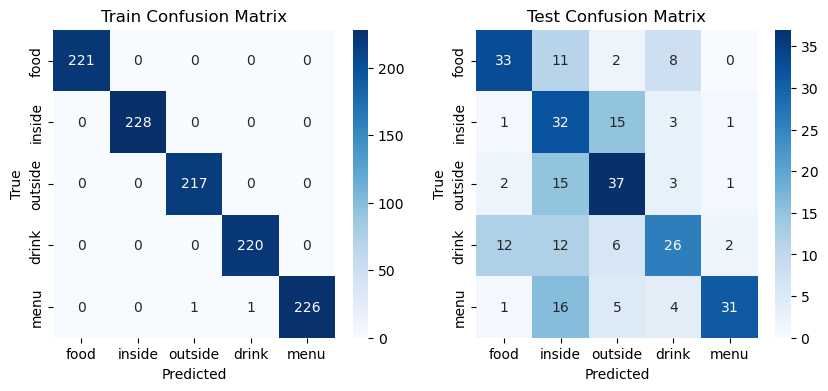

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step 


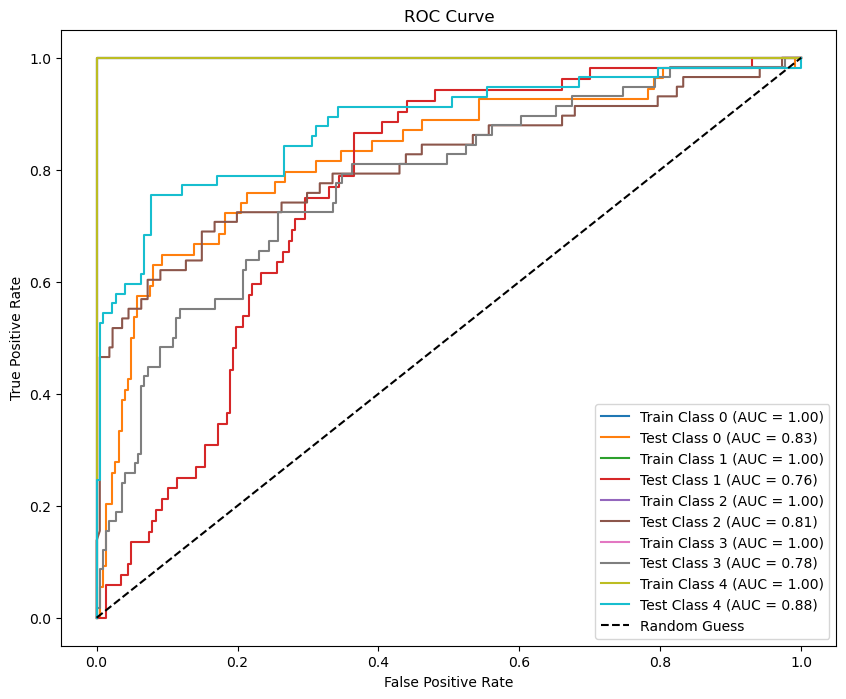

Model Saved Successfully


In [92]:
# Build CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 classes
])

# Compile the model
if y_one_hot.ndim == 1:  # Sparse categorical crossentropy
    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
else:  # Categorical crossentropy
    cnn_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

start_time = time.time()
# Train the model
history = cnn_model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_data=(X_val, Y_val))
end_time = time.time()

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Evaluate
val_loss, val_accuracy = cnn_model.evaluate(X_val, Y_val)
print(f'Validation Accuracy: {val_accuracy:.4f}')

# Calculate Train and Test Accuracy
train_loss, train_accuracy = cnn_model.evaluate(X_train, Y_train, verbose=0)
test_loss, test_accuracy = cnn_model.evaluate(X_val, Y_val, verbose=0)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
# Predict classes for training and test data
y_train_pred = np.argmax(cnn_model.predict(X_train), axis=1)
y_test_pred = np.argmax(cnn_model.predict(X_val), axis=1)

# Convert one-hot encoded labels back to integers for confusion matrix
y_train_true = np.argmax(Y_train, axis=1) if Y_train.ndim > 1 else Y_train
y_test_true = np.argmax(Y_val, axis=1) if Y_val.ndim > 1 else Y_val

# Compute confusion matrix
train_cm = confusion_matrix(y_train_true, y_train_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

# Plot confusion matrix for training data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot confusion matrix for test data
plt.subplot(1, 2, 2)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve and AUC
# Predict probabilities for each class
y_train_prob = cnn_model.predict(X_train)
y_test_prob = cnn_model.predict(X_val)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(5):  # Assuming 5 classes
    # Train ROC
    fpr_train, tpr_train, _ = roc_curve(y_train_true == i, y_train_prob[:, i])
    auc_train = roc_auc_score(y_train_true == i, y_train_prob[:, i])
    
    # Test ROC
    fpr_test, tpr_test, _ = roc_curve(y_test_true == i, y_test_prob[:, i])
    auc_test = roc_auc_score(y_test_true == i, y_test_prob[:, i])
    
    # Plot ROC curves
    plt.plot(fpr_train, tpr_train, label=f'Train Class {i} (AUC = {auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, label=f'Test Class {i} (AUC = {auc_test:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

save_model(cnn_model, "D:\Models", "cnn")
print("Model Saved Successfully")

In [142]:
from sklearn.metrics import classification_report

# Compute F1 Scores for Training Set
train_report = classification_report(y_train_true, y_train_pred, output_dict=True)
print("\nTraining F1 Scores:")
for class_label, metrics in train_report.items():
    if class_label.isdigit():  # Ignore 'accuracy', 'macro avg', 'weighted avg'
        print(f"Class {class_label} F1-Score: {metrics['f1-score']:.4f}")

# Compute F1 Scores for Test Set
test_report = classification_report(y_test_true, y_test_pred, output_dict=True)
print("\nTesting F1 Scores:")
for class_label, metrics in test_report.items():
    if class_label.isdigit():
        print(f"Class {class_label} F1-Score: {metrics['f1-score']:.4f}")



Training F1 Scores:
Class 0 F1-Score: 0.0000
Class 1 F1-Score: 0.3505
Class 2 F1-Score: 0.0000
Class 3 F1-Score: 0.0604
Class 4 F1-Score: 0.1147

Testing F1 Scores:
Class 0 F1-Score: 0.0000
Class 1 F1-Score: 0.3234
Class 2 F1-Score: 0.0000
Class 3 F1-Score: 0.0870
Class 4 F1-Score: 0.1081


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: 2


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

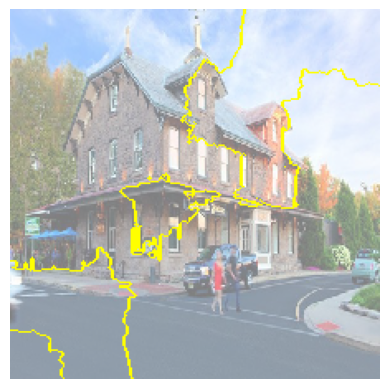

(<lime.lime_image.ImageExplanation at 0x2833da55c10>,
 array([[[0.68039216, 0.80588236, 0.99803922],
         [0.68431373, 0.80784315, 0.99803922],
         [0.69215687, 0.80980393, 1.        ],
         ...,
         [0.86470589, 0.89607844, 0.99215686],
         [0.86666667, 0.90000001, 0.99019608],
         [0.87254903, 0.90784314, 0.99803922]],
 
        [[0.68039216, 0.80980393, 1.        ],
         [0.67647059, 0.8019608 , 0.99411765],
         [0.67843138, 0.8019608 , 0.99215686],
         ...,
         [0.86274511, 0.89803922, 0.99215686],
         [0.85882354, 0.89411765, 0.98823529],
         [0.85882354, 0.89411765, 0.98431373]],
 
        [[0.67254902, 0.80588236, 1.        ],
         [0.67450981, 0.8019608 , 0.99803922],
         [0.67843138, 0.80392158, 1.        ],
         ...,
         [0.85490197, 0.89607844, 0.98823529],
         [0.8509804 , 0.89019608, 0.98823529],
         [0.85294119, 0.89215687, 0.99019608]],
 
        ...,
 
        [[0.57058824, 0.61764706, 

In [145]:
explain_with_lime_cnn_dnn(X_val[0], cnn_model)

Optimized CNN Model (With Overfitting Prevention & Efficiency Improvements)


Training with batch_size=16, epochs=5, activation=relu
Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 17s 221ms/step - accuracy: 0.2767 - loss: 2.5351 - val_accuracy: 0.4982 - val_loss: 1.2360
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.5393 - loss: 1.1951 - val_accuracy: 0.5986 - val_loss: 1.0756
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.7179 - loss: 0.8133 - val_accuracy: 0.5341 - val_loss: 1.2054
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.8522 - loss: 0.4615 - val_accuracy: 0.5412 - val_loss: 1.4274
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.9416 - loss: 0.1922 - val_accuracy: 0.5556 - val_loss: 2.0027
Validation Accuracy: 0.5556

Training with batch_size=16, epochs=5, activation=tanh
Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 17s 221ms/step - accuracy: 0.2009 - loss: 7.3459 - val_accuracy: 0.1864 - val_loss: 1.7557
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.2224 - loss: 1.7040 - val_

Validation Accuracy: 0.2043

Best Model Hyperparameters:
{'batch_size': 32, 'epochs': 5, 'activation': 'relu'}
Best Validation Accuracy: 0.5771
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5495 - loss: 1.4512 
Validation Loss: 1.335970163345337, Validation Accuracy: 0.5770609378814697
Training Time: 952.71 seconds
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5495 - loss: 1.4512 
Validation Accuracy: 0.5771
Train Accuracy: 0.9372
Test Accuracy: 0.5771
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


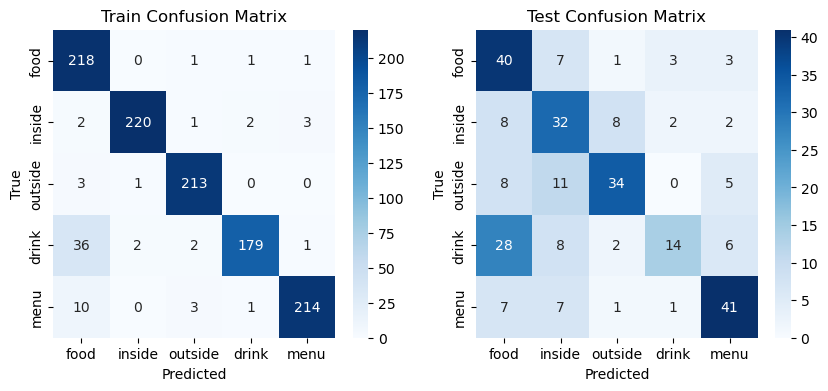

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step 


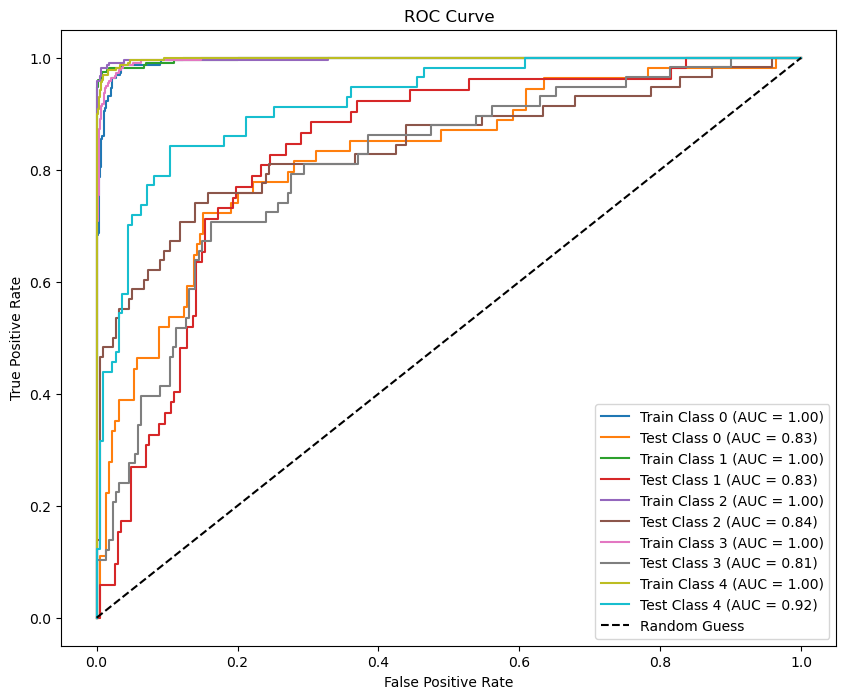

Model Saved Successfully


In [147]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Function to create the CNN model
def build_cnn(activation='relu'):
    model = Sequential([
        Conv2D(32, (3, 3), activation=activation, input_shape=(224, 224, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation=activation),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation=activation),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation=activation),
        Dense(5, activation='softmax')  # 5 classes
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define hyperparameter grid manually
batch_sizes = [16, 32]
epochs_list = [5, 10]
activations = ['relu', 'tanh']

best_model = None
best_accuracy = 0
best_params = {}

start_time = time.time()
# Iterate through hyperparameter combinations
for batch_size in batch_sizes:
    for epochs in epochs_list:
        for activation in activations:
            print(f"\nTraining with batch_size={batch_size}, epochs={epochs}, activation={activation}")
            
            model = build_cnn(activation)
            history = model.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val, Y_val), verbose=1)

            # Evaluate model on validation data
            val_loss, val_accuracy = model.evaluate(X_val, Y_val, verbose=0)
            print(f'Validation Accuracy: {val_accuracy:.4f}')

            # Track the best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_model = model
                best_params = {'batch_size': batch_size, 'epochs': epochs, 'activation': activation}
end_time = time.time()

# Print best parameters
print("\nBest Model Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_accuracy:.4f}")

# Save the best model
best_model.save("best_cnn_model.h5")

# Evaluate the model on validation data
val_loss, val_acc = best_model.evaluate(X_val, Y_val)
print(f"Validation Loss: {val_loss}, Validation Accuracy: {val_acc}")

# Calculate training time
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Evaluate
val_loss, val_accuracy = best_model.evaluate(X_val, Y_val)
print(f'Validation Accuracy: {val_accuracy:.4f}')

# Calculate Train and Test Accuracy
train_loss, train_accuracy = best_model.evaluate(X_train, Y_train, verbose=0)
test_loss, test_accuracy = best_model.evaluate(X_val, Y_val, verbose=0)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
# Predict classes for training and test data
y_train_pred = np.argmax(best_model.predict(X_train), axis=1)
y_test_pred = np.argmax(best_model.predict(X_val), axis=1)

# Convert one-hot encoded labels back to integers for confusion matrix
y_train_true = np.argmax(Y_train, axis=1) if Y_train.ndim > 1 else Y_train
y_test_true = np.argmax(Y_val, axis=1) if Y_val.ndim > 1 else Y_val

# Compute confusion matrix
train_dnn = confusion_matrix(y_train_true, y_train_pred)
test_dnn = confusion_matrix(y_test_true, y_test_pred)

# Plot confusion matrix for training data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(train_dnn, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot confusion matrix for test data
plt.subplot(1, 2, 2)
sns.heatmap(test_dnn, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve and AUC
# Predict probabilities for each class
y_train_prob = best_model.predict(X_train)
y_test_prob = best_model.predict(X_val)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(5):  # Assuming 5 classes
    # Train ROC
    fpr_train, tpr_train, _ = roc_curve(y_train_true == i, y_train_prob[:, i])
    auc_train = roc_auc_score(y_train_true == i, y_train_prob[:, i])
    
    # Test ROC
    fpr_test, tpr_test, _ = roc_curve(y_test_true == i, y_test_prob[:, i])
    auc_test = roc_auc_score(y_test_true == i, y_test_prob[:, i])
    
    # Plot ROC curves
    plt.plot(fpr_train, tpr_train, label=f'Train Class {i} (AUC = {auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, label=f'Test Class {i} (AUC = {auc_test:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

save_model(best_model, "D:\Models", "grid_search_cnn")
print("Model Saved Successfully")